In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
from smooth_POD_ROM.plots_paper import Fig3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)

In [4]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 10,  # 25
    "g": small_saw_tooth, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
}

In [5]:
def Fig3(x, mu_train, X_train, X_train_s):
    fig = plt.figure(figsize=(page_width_in, page_width_in / 2), facecolor="white")
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    for i in range(len(mu_train)):
        ax1.plot(np.ones_like(x) * mu_train[i], x, X_train[i], "k-", lw=1)
        ax2.plot(np.ones_like(x) * mu_train[i], x, X_train_s[i], "k-", lw=1)
    for ax in (ax1, ax2):
        ax.xaxis.labelpad = -5
        ax.yaxis.labelpad = -5
        xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
        xticks = [0.0, 0.5, 1.0]
        yticks = [0.0, 0.5, 1.0]
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_zticks([0.5, 1.0])
        ax.tick_params(axis="x", which="major", pad=-5)
        ax.tick_params(axis="y", which="major", pad=-2)
        ax.tick_params(axis="z", which="major", pad=0)
        ax.set_yticklabels(yticks, va="baseline", ha="left")
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            for tick in axis.get_major_ticks():
                # for some reasons it does not match
                tick.label1.set_fontsize(8)
            axis.pane.set_edgecolor("white")

        ax.grid(False)
        ax.set_facecolor("white")
        ax.xaxis.pane.fill = False  # Remove the background pane
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$x$")
    plt.show()

def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

10


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.05050000, 5.00000000, 0.09566342, 0.08180366, 0.04527064, -52.6772
250, 0.08350000, 5.00000000, 0.09566342, 0.08349661, 0.05916596, -38.1520
250, 0.01750000, 5.00000000, 0.09566342, 0.08203655, 0.09232801, -3.4866
250, 0.05050000, 8.33333333, 0.09566342, 0.08180366, 0.05086687, -46.8272
250, 0.05050000, 1.66666667, 0.09566342, 0.08180366, 0.04932521, -48.4388
250, 0.08350000, 1.66666667, 0.09566342, 0.08349661, 0.05577454, -41.6971
250, 0.01750000, 1.66666667, 0.09566342, 0.08203655, 0.11225259, 17.3412
250, 0.06150000, 5.00000000, 0.09566342, 0.08244771, 0.05060460, -47.1014
250, 0.03950000, 5.00000000, 0.09566342, 0.08116950, 0.03985743, -58.3358
250, 0.05050000, 6.11111111, 0.09566342, 0.08180366, 0.04713555, -50.7277
250, 0.05050000, 3.88888889, 0.09566342, 0.08180366, 0.04379502, -54.2197
250, 0.08350000, 8.33333333, 0.09566342, 0.08349661, 0.06658315, -30.3985
250, 0.01750000, 8.33333333, 0.09566342, 0.08203655, 0.05670751, -40.7218
250, 0.03950000, 6.11111111, 0.09566342,

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


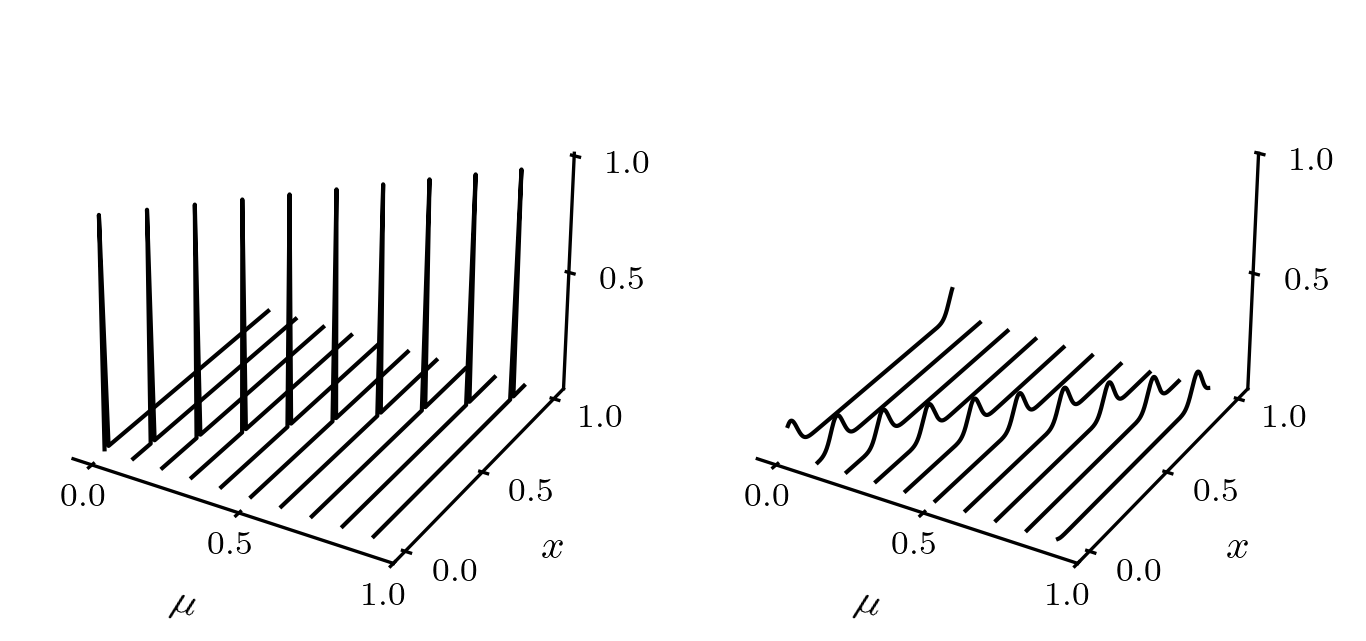

average improvement (250 iterations): 59.99


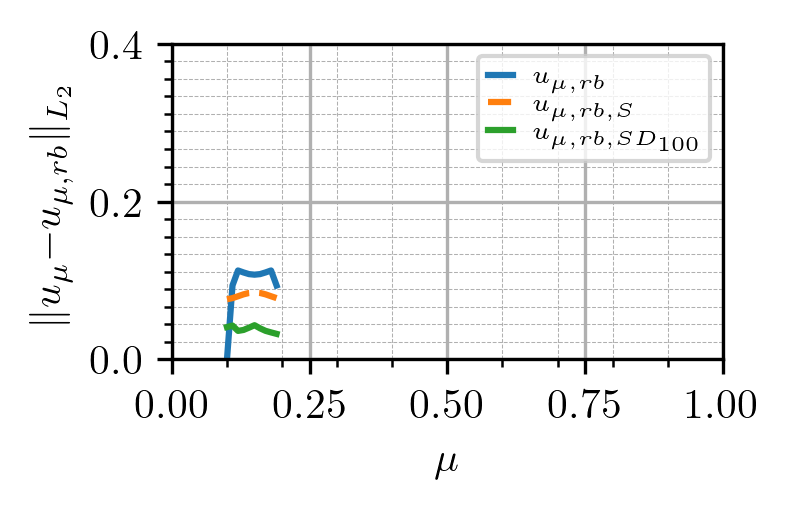

20


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.02550000, 5.00000000, 0.08464792, 0.07583063, 0.03888381, -54.0641
250, 0.04183333, 5.00000000, 0.08464792, 0.07923115, 0.03864276, -54.3488
250, 0.00916667, 5.00000000, 0.08464792, 0.07461352, 0.07037657, -16.8597
250, 0.02550000, 8.33333333, 0.08464792, 0.07583063, 0.03831455, -54.7366
250, 0.02550000, 1.66666667, 0.08464792, 0.07583063, 0.03605110, -57.4105
250, 0.04183333, 1.66666667, 0.08464792, 0.07923115, 0.03546188, -58.1066
250, 0.00916667, 1.66666667, 0.08464792, 0.07461352, 0.10694924, 26.3460
250, 0.04183333, 8.33333333, 0.08464792, 0.07923115, 0.04445931, -47.4774
250, 0.00916667, 8.33333333, 0.08464792, 0.07461352, 0.05037617, -40.4874
250, 0.04727778, 1.66666667, 0.08464792, 0.08004367, 0.03703406, -56.2493
250, 0.03638889, 1.66666667, 0.08464792, 0.07826568, 0.03490681, -58.7623
250, 0.04183333, 2.77777778, 0.08464792, 0.07923115, 0.03553418, -58.0212
250, 0.04183333, 0.55555556, 0.08464792, 0.07923115, 0.04579059, -45.9047
250, 0.03638889, 2.77777778, 0.08464792

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


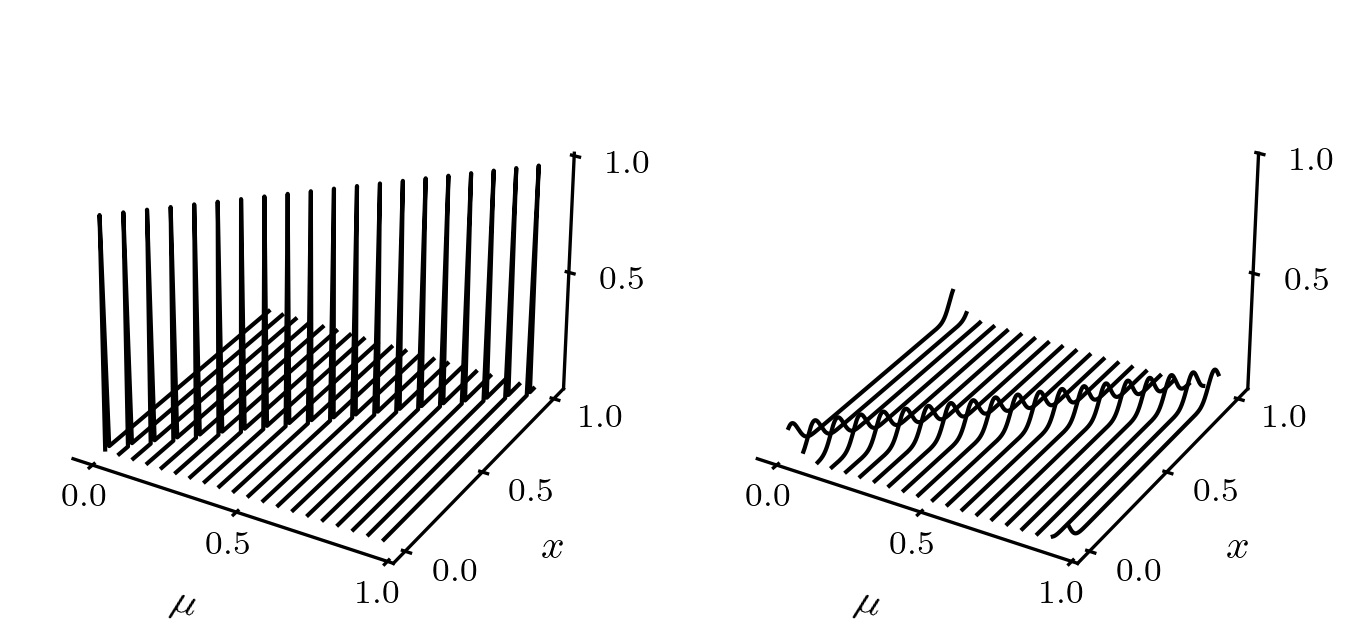

average improvement (250 iterations): 58.83


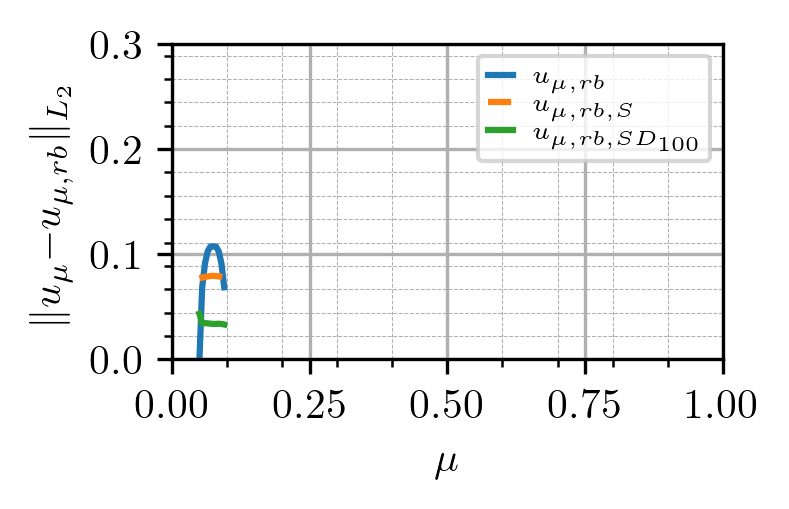

50


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.01050000, 5.00000000, 0.05706162, 0.05937515, 0.05309460, -6.9522
250, 0.01683333, 5.00000000, 0.05706162, 0.06667458, 0.04823923, -15.4612
250, 0.00416667, 5.00000000, 0.05706162, 0.05293240, 0.05387974, -5.5762
250, 0.01050000, 8.33333333, 0.05706162, 0.05937515, 0.05087654, -10.8393
250, 0.01050000, 1.66666667, 0.05706162, 0.05937515, 0.04931224, -13.5807
250, 0.01683333, 8.33333333, 0.05706162, 0.06667458, 0.04371761, -23.3853
250, 0.01683333, 1.66666667, 0.05706162, 0.06667458, 0.04937454, -13.4715
250, 0.00416667, 8.33333333, 0.05706162, 0.05293240, 0.05532519, -3.0431
250, 0.00416667, 1.66666667, 0.05706162, 0.05293240, 0.07311778, 28.1383
250, 0.01894444, 8.33333333, 0.05706162, 0.06853179, 0.04164071, -27.0250
250, 0.01472222, 8.33333333, 0.05706162, 0.06453014, 0.04618182, -19.0667
250, 0.01683333, 9.44444444, 0.05706162, 0.06667458, 0.04234490, -25.7909
250, 0.01683333, 7.22222222, 0.05706162, 0.06667458, 0.04540972, -20.4198
250, 0.01894444, 9.44444444, 0.05706162, 0

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


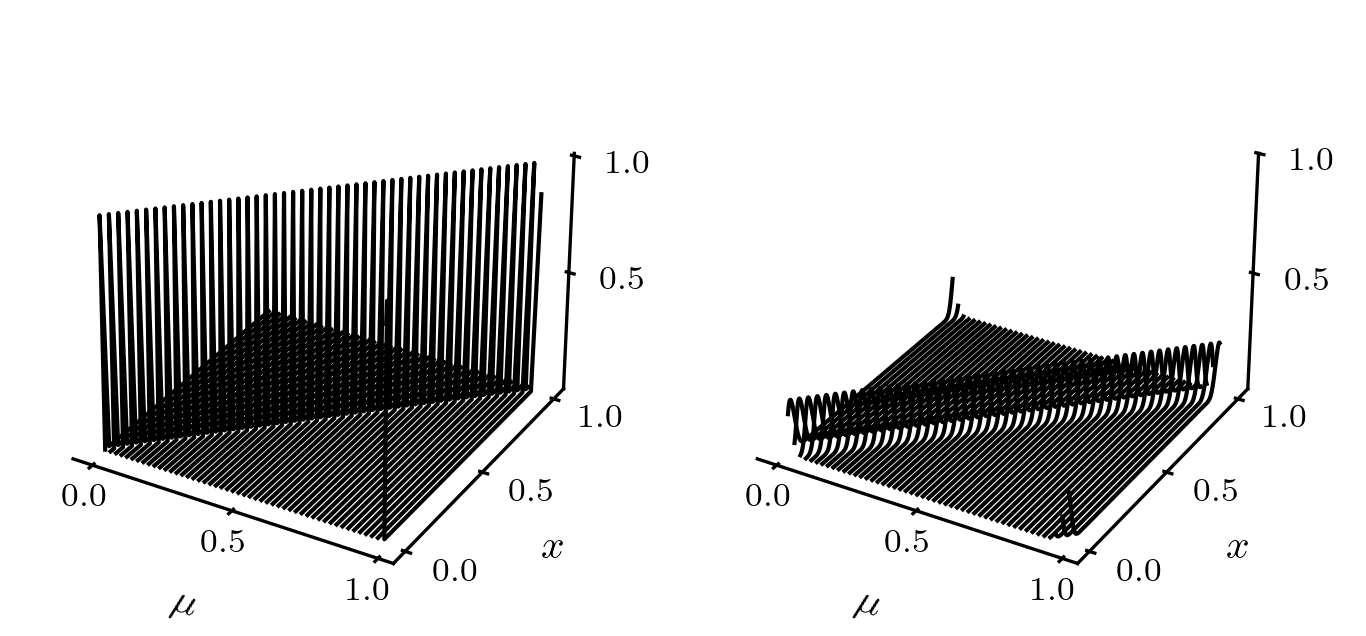

average improvement (250 iterations): 30.18


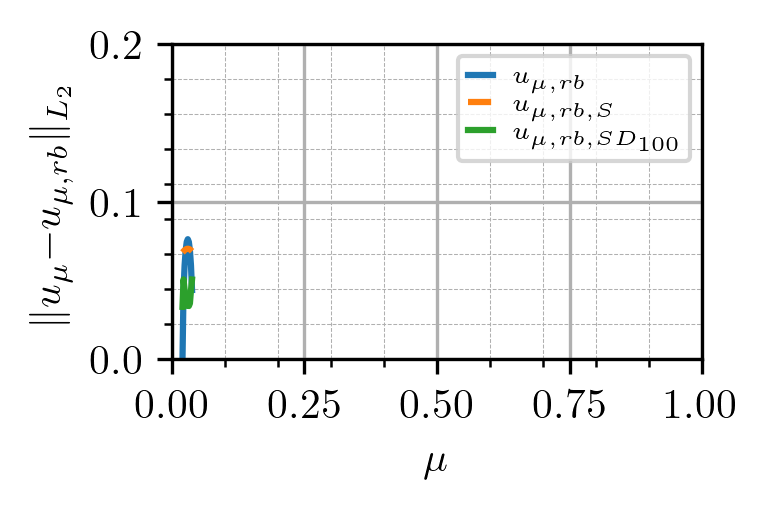

100


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.00550000, 5.00000000, 0.03892720, 0.04231179, 0.05707234, 46.6130
250, 0.00850000, 5.00000000, 0.03892720, 0.05015465, 0.05580617, 43.3603
250, 0.00250000, 5.00000000, 0.03892720, 0.03607735, 0.04339589, 11.4796
250, 0.00550000, 8.33333333, 0.03892720, 0.04231179, 0.05638721, 44.8530
250, 0.00550000, 1.66666667, 0.03892720, 0.04231179, 0.04404407, 13.1447
250, 0.00250000, 8.33333333, 0.03892720, 0.03607735, 0.05279162, 35.6163
250, 0.00250000, 1.66666667, 0.03892720, 0.03607735, 0.04719918, 21.2499
250, 0.00850000, 8.33333333, 0.03892720, 0.05015465, 0.05328442, 36.8822
250, 0.00850000, 1.66666667, 0.03892720, 0.05015465, 0.05405294, 38.8565
250, 0.00350000, 5.00000000, 0.03892720, 0.03756097, 0.05197257, 33.5122
250, 0.00150000, 5.00000000, 0.03892720, 0.03592660, 0.04417127, 13.4715
250, 0.00250000, 6.11111111, 0.03892720, 0.03607735, 0.04852022, 24.6435
250, 0.00250000, 3.88888889, 0.03892720, 0.03607735, 0.03742465, -3.8599
250, 0.00350000, 3.88888889, 0.03892720, 0.03756097

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


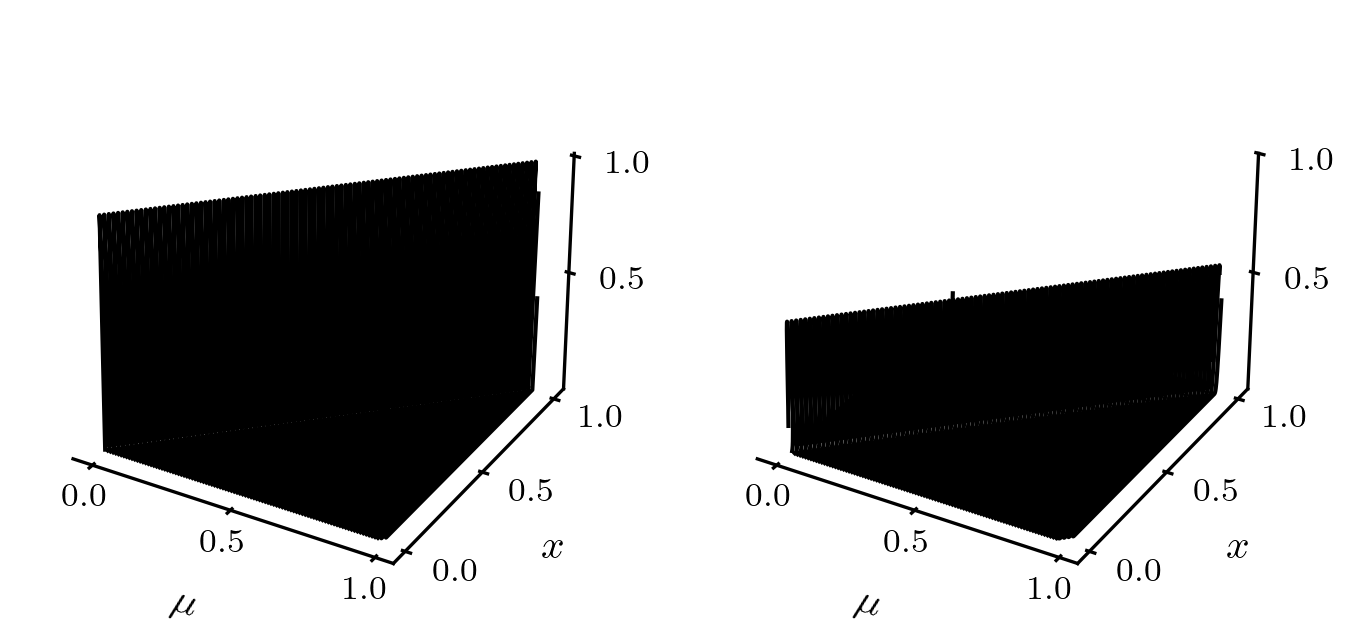

average improvement (250 iterations): 34.75


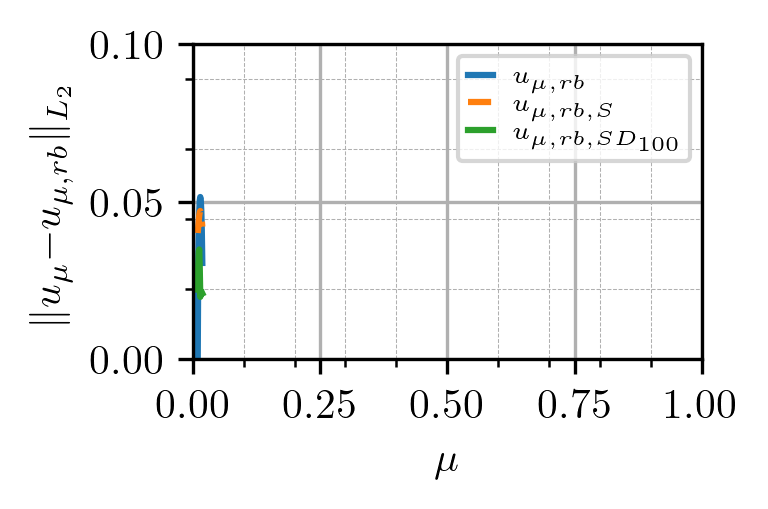

200


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.00300000, 5.00000000, 0.02625479, 0.02944674, 0.04933318, 87.9016
250, 0.00433333, 5.00000000, 0.02625479, 0.03400900, 0.05281976, 101.1814
250, 0.00166667, 5.00000000, 0.02625479, 0.02550858, 0.03302904, 25.8020
250, 0.00300000, 8.33333333, 0.02625479, 0.02944674, 0.05136134, 95.6265
250, 0.00300000, 1.66666667, 0.02625479, 0.02944674, 0.02804495, 6.8184
250, 0.00433333, 1.66666667, 0.02625479, 0.03400900, 0.04110152, 56.5486
250, 0.00166667, 1.66666667, 0.02625479, 0.02550858, 0.02160495, -17.7104
250, 0.00433333, 8.33333333, 0.02625479, 0.03400900, 0.05291049, 101.5270
250, 0.00166667, 8.33333333, 0.02625479, 0.02550858, 0.04306169, 64.0146
250, 0.00211111, 1.66666667, 0.02625479, 0.02663894, 0.01809139, -31.0930
250, 0.00122222, 1.66666667, 0.02625479, 0.02480081, 0.03101839, 18.1437
250, 0.00166667, 2.77777778, 0.02625479, 0.02550858, 0.02092325, -20.3069
250, 0.00166667, 0.55555556, 0.02625479, 0.02550858, 0.02980206, 13.5109
250, 0.00211111, 2.77777778, 0.02625479, 0.0266

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


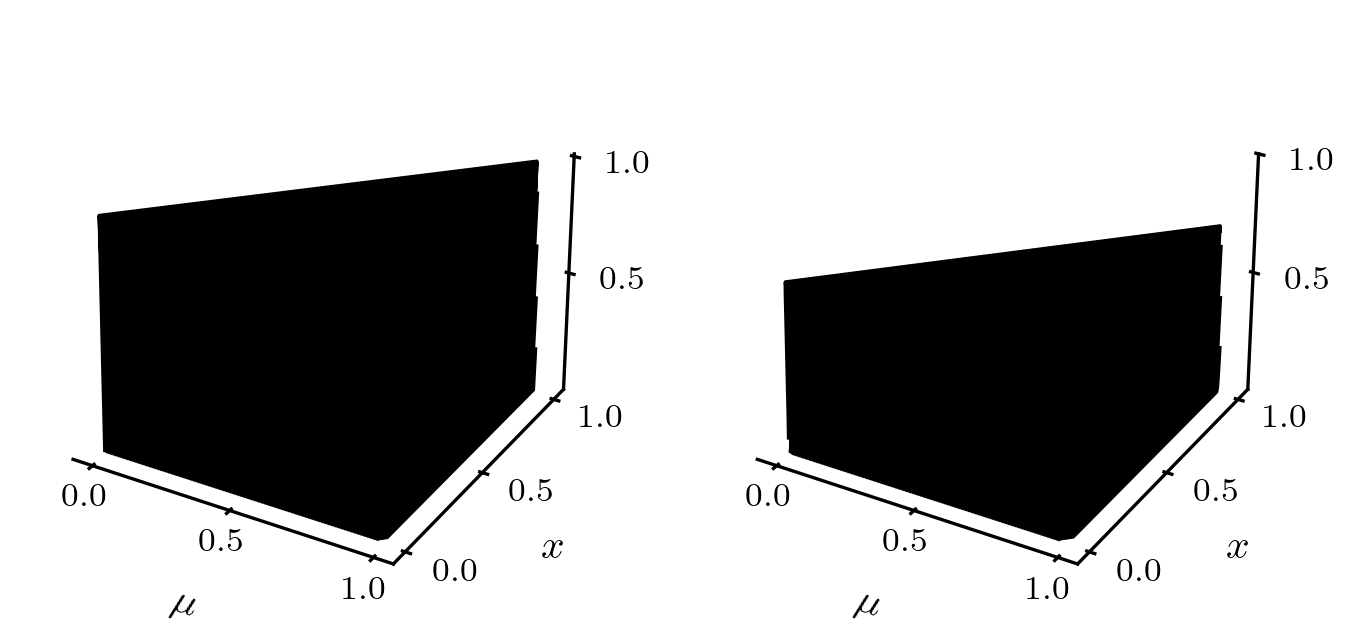

average improvement (250 iterations): 35.85


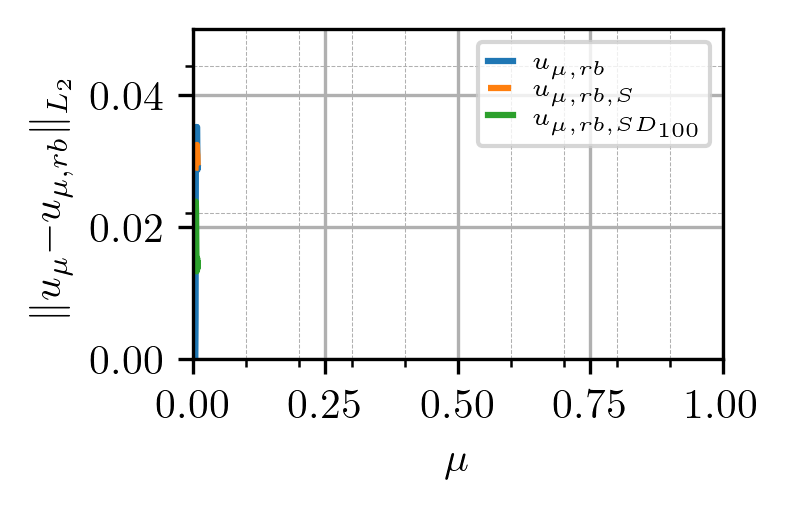

In [6]:
for rank, ylim in zip([10, 50, 100], (0.4, 0.2, 0.1)):
    print(rank)
    case["rank"] = rank
    case["n_train"] = rank
    parameters = optimize_hyperparameters(case)

    case["sigma"], case["c"] = parameters[0], parameters[1]
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    for rank, ylim in zip([10, 50, 100], (0.4, 0.2, 0.1)):
        case["rank"] = rank
        case["n_train"] = rank
        mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
        mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
        mu_val, X_val, X_val_s = make_data_rw(mu_train[0], mu_train[-1], n_samples=1000, **case)
    
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
        X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)
        
        Fig3(x, mu_train, X_train, X_train_s)
    
        # replace test with val
        mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
            X_test, X_test_ROM, X_test_sROM, X_test_sROMs
        )
    
        eROM = L2_error_rw(X_test_ROM, X_test)
        esROM = L2_error_rw(X_test_sROM, X_test)
        esROMs = L2_error_rw(X_test_sROMs, X_test)
        imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
        print("average improvement ({:.0f} iterations): {:.2f}".format(case["num_iter"], imp1))
        fig, ax = Fig6(mu_test, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)
        plt.show()
    
        #for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):


In [7]:
asd

NameError: name 'asd' is not defined

In [ ]:
n_x = 1000
n_train = 50
n_test = 10
num_iter1 = 100
#num_iter2 = 250
# num_iter3 = 1000
#num_iter4 = 2500

In [ ]:
rank = n_train
dx = 1 / n_x
shape = (n_x,)
clip = True

In [ ]:
x = np.linspace(0, 1, n_x, endpoint=False)
mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

g = rectangular_pulse

X_train = snapshots(g, x, mu_train)
X_test = snapshots(g, x, mu_test)

In [ ]:
#sigma, c = optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, rank)
rank, sigma, c = 10, 0.046817495544034825, 3.4777597632478527  # -77.5, num_iter2=250, n_test=10
rank, sigma, c = 20, 0.04709477073255084, 0.9473123624789438  # -64.5, num_iter2=250, n_test=10
rank, sigma, c = 50, 0.010637015820358114, 1.1437423194705931  # -53.5667, num_iter2=250, n_test=10

In [ ]:
X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma / dx, x.shape, truncate=12)

Fig3(x, mu_train, X_train, X_train_s)

In [ ]:
def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

In [ ]:
for rank, ylim in zip([10, 20, 50], (0.4, 0.3, 0.2)):
    for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):
        print(rank, sigma, c)
        mu_train = np.linspace([0.0], [1.0], rank, endpoint=False)
        X_train = snapshots(g, x, mu_train)
        X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)

        mu_val = x.copy()
        interpolatable = (mu_train[0] < mu_val) & (mu_val < mu_train[-1])
        mu_val = mu_val[interpolatable][:, None]
        X_val = snapshots(g, x, mu_val)
        X_val_s = smoothen(X_val, sigma / dx, x.shape, truncate=12)
        
        Fig3(x, mu_train, X_train, X_train_s)

        print("build ROM and predict")
        standard_rom = train_ROM(mu_train, X_train, rank=rank)
        smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
        X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
        X_val_ROM = standard_rom.predict(mu_val).snapshots_matrix.T
        X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
        X_val_sROM = smooth_rom.predict(mu_val).snapshots_matrix.T


        print("model performance validation")
        X_val_sROMs = post_process(
            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter1, shape, clip=clip, progress=False
        )
#        X_val_sROMs2 = post_process(
#            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter2, shape, clip=clip, progress=True
#        )
        eROM = L2_error(X_val_ROM, X_val)
        esROM = L2_error(X_val_sROM, X_val)
        esROMs = L2_error(X_val_sROMs, X_val)
#        esROMs2 = L2_error(X_val_sROMs2, X_val)
        imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
#        imp2 = 100 - np.mean(esROMs2) / np.mean(eROM) * 100
        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter1, imp1))
#        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter2, imp2))

        fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)